# Scientific retractions EDA

Exploratory analysis of the [Global Scientific Retractions 1927–2026](https://www.kaggle.com/datasets/kanchana1990/global-scientific-retractions-19272026) dataset. This notebook uses **retraction** (withdrawn papers) in the statistical sense—not document redaction.

**Focus:** which disciplines (fields), countries, and retraction reasons show up most, and how time-to-retraction and authorship vary by field.

In [1]:
import re
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Download latest version
dataset_path = kagglehub.dataset_download("kanchana1990/global-scientific-retractions-19272026")
print("Path to dataset files:", dataset_path)

# Resolve CSV (robust to layout changes)
_root = Path(dataset_path)
_csv_candidates = list(_root.rglob("global_scientific_retractions_1927_2026.csv"))
if not _csv_candidates:
    _csv_candidates = list(_root.rglob("*.csv"))
assert _csv_candidates, f"No CSV found under {_root}"
csv_path = _csv_candidates[0]
print("Loading:", csv_path)

df = pd.read_csv(csv_path)

/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|█████████████| 12.4M/12.4M [00:02<00:00, 4.42MB/s]

Extracting files...


Path to dataset files: /Users/nicapotato/.cache/kagglehub/datasets/kanchana1990/global-scientific-retractions-19272026/versions/1
Loading: /Users/nicapotato/.cache/kagglehub/datasets/kanchana1990/global-scientific-retractions-19272026/versions/1/global_scientific_retractions_1927_2026.csv


## Dataset profile

Shape, dtypes, missing values, and numeric summaries. Charts below mirror the starter EDA: retractions over time, top countries, distribution of years to retraction, and author counts.

In [2]:
print("shape:", df.shape)
print()
df.info()
print()
print("Missing per column (top 15):")
print(df.isna().sum().sort_values(ascending=False).head(15))
print()
df.describe()

shape: (64267, 27)

<class 'pandas.DataFrame'>
RangeIndex: 64267 entries, 0 to 64266
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   record_id              64267 non-null  int64  
 1   title                  64267 non-null  str    
 2   journal                64267 non-null  str    
 3   publisher              64267 non-null  str    
 4   country                64267 non-null  str    
 5   author                 64267 non-null  str    
 6   subject                64267 non-null  str    
 7   articletype            64267 non-null  str    
 8   reason                 64267 non-null  str    
 9   retractiondate         64267 non-null  str    
 10  retraction_year        64267 non-null  int64  
 11  retractiondoi          59721 non-null  str    
 12  retractionpubmedid     59235 non-null  float64
 13  originalpaperdate      64267 non-null  str    
 14  original_year          64267 non-null  int64 

,record_id,retraction_year,retractionpubmedid,original_year,originalpaperpubmedid,years_to_retraction,author_count,reason_count,subject_count,title_len,title_word_count,has_retraction_doi,has_original_doi
count,64267.000000,64267.000000,5.923500e+04,64267.000000,5.920200e+04,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000
mean,35121.063190,2018.560303,1.579884e+07,2016.216519,1.390603e+07,2.397444,4.075949,3.935643,2.729395,102.469152,13.614841,0.929264,0.908476
std,20469.435739,6.062955,1.727866e+07,6.435023,1.543258e+07,3.446243,3.068341,2.627242,1.166718,35.604484,4.723548,0.256386,0.288356
min,1.000000,1927.000000,0.000000e+00,1923.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,16950.500000,2014.000000,0.000000e+00,2011.000000,0.000000e+00,0.391513,2.000000,2.000000,2.000000,78.000000,10.000000,1.000000,1.000000
50%,35156.000000,2021.000000,0.000000e+00,2018.000000,0.000000e+00,1.311431,3.000000,3.000000,3.000000,99.000000,13.000000,1.000000,1.000000
75%,53052.500000,2023.000000,3.577182e+07,2022.000000,3.076687e+07,2.806297,5.000000,5.000000,3.000000,123.000000,16.000000,1.000000,1.000000
max,69968.000000,2026.000000,4.190587e+07,2026.000000,4.146144e+07,81.100616,88.000000,17.000000,10.000000,384.000000,57.000000,1.000000,1.000000


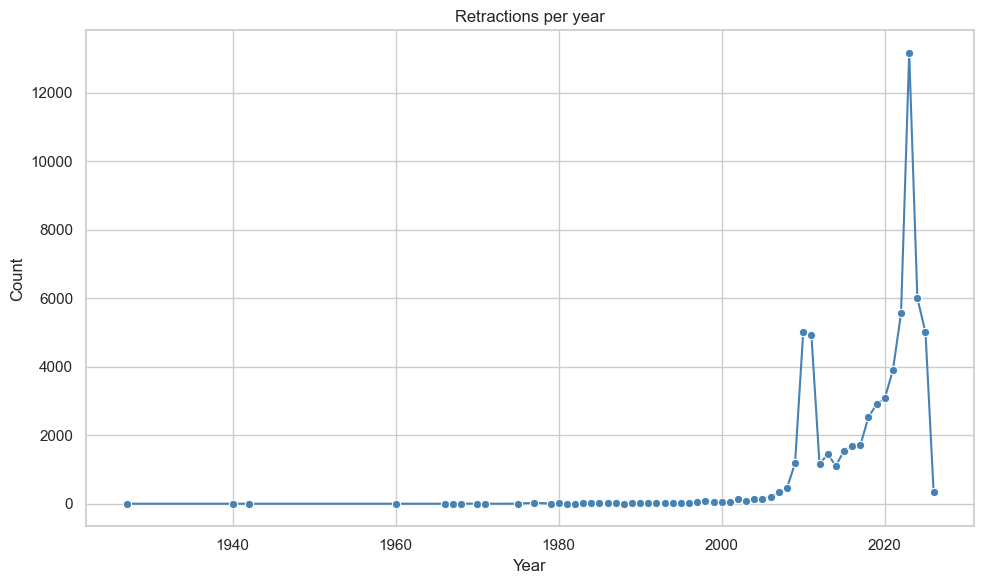

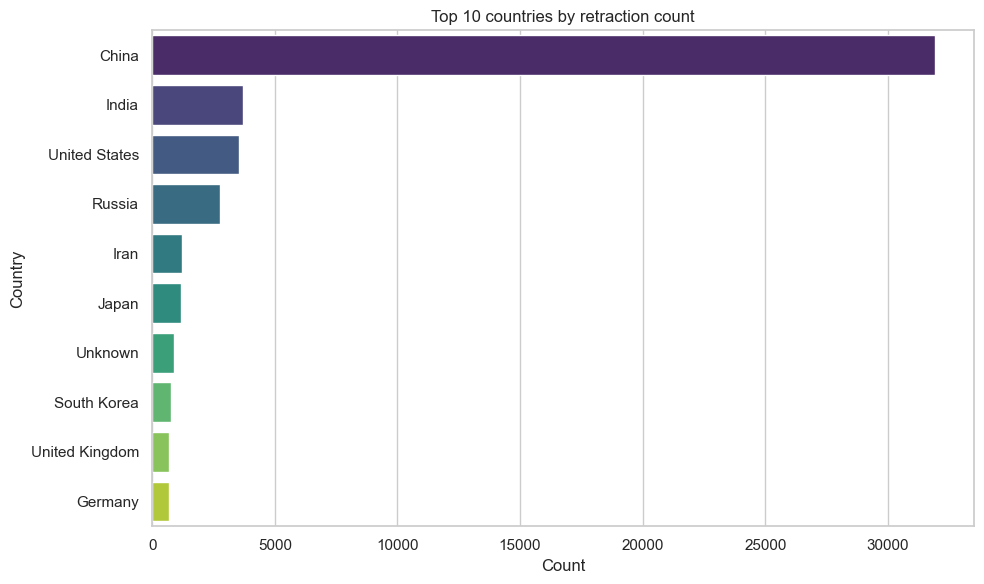

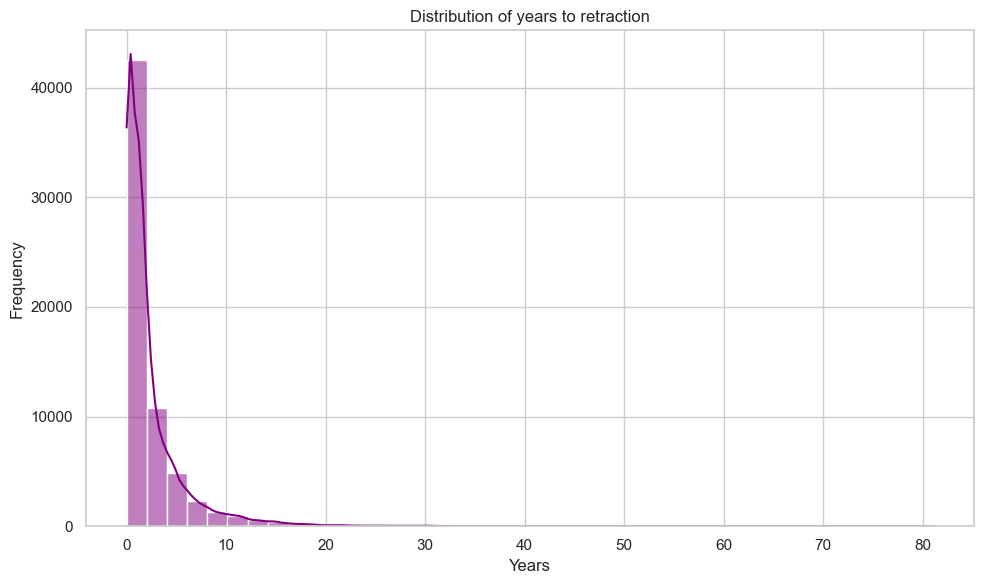

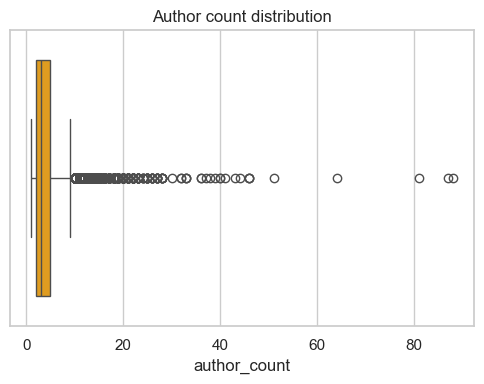

In [3]:
# Retractions over time
plt.figure(figsize=(10, 6))
year_counts = df["retraction_year"].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="steelblue")
plt.title("Retractions per year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Top countries
plt.figure(figsize=(10, 6))
top_countries = df["country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 countries by retraction count")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Years to retraction
plt.figure(figsize=(10, 6))
sns.histplot(df["years_to_retraction"].dropna(), bins=40, kde=True, color="purple")
plt.title("Distribution of years to retraction")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Author count (single axis boxplot)
plt.figure(figsize=(5, 4))
sns.boxplot(x=df["author_count"], color="orange")
plt.title("Author count distribution")
plt.tight_layout()
plt.show()

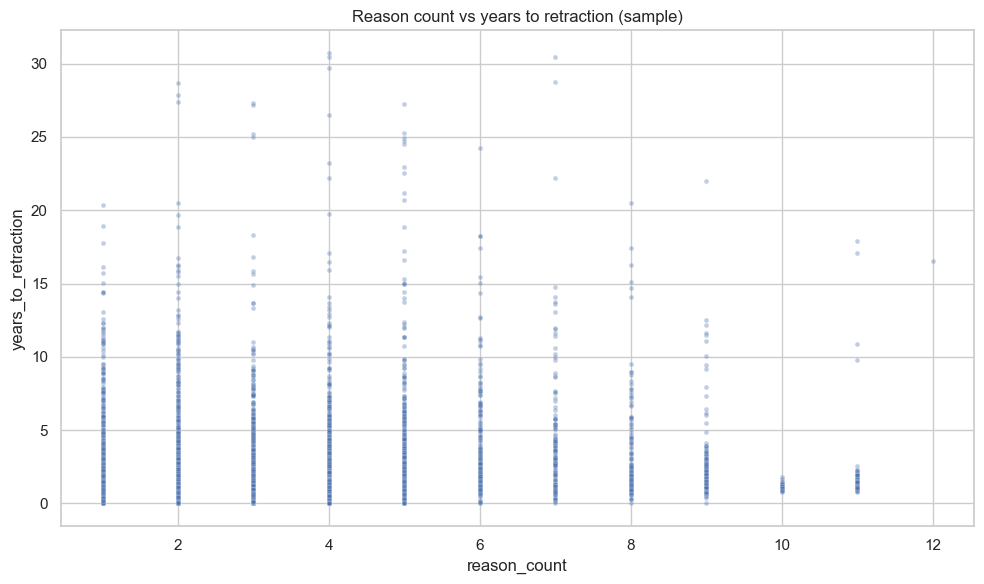

In [4]:
# Reason count vs years to retraction (starter notebook pattern)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="reason_count",
    y="years_to_retraction",
    alpha=0.35,
    s=12,
)
plt.title("Reason count vs years to retraction (sample)")
plt.tight_layout()
plt.show()

## Discipline (field) from `subject`

Each `subject` string lists one or more tags like `(BLS) Biology - Cellular;(HSC) Medicine - ...`. We extract the **first three-letter code** in parentheses as `primary_code` (e.g. `BLS`, `HSC`). Rows with no match are labeled `Unknown`. The dataset already provides `subject_count` for how many tags apply per paper.

Primary discipline code counts (top 25):
primary_code
BLS        20852
PHY        11927
HSC        11711
Unknown     8024
SOC         6597
ENV         3230
HUM         1926
Name: count, dtype: int64


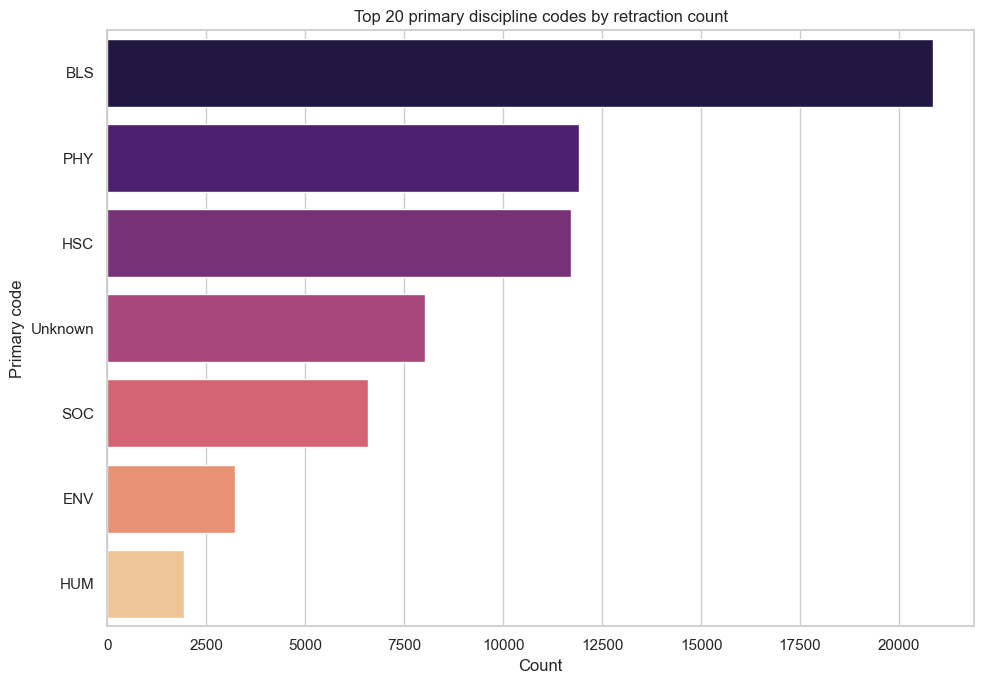

In [5]:
_code_re = re.compile(r"\(([A-Z]{3})\)")


def primary_discipline_code(subject: str) -> str:
    if pd.isna(subject) or not str(subject).strip():
        return "Unknown"
    m = _code_re.search(str(subject))
    return m.group(1) if m else "Unknown"


df["primary_code"] = df["subject"].map(primary_discipline_code)

print("Primary discipline code counts (top 25):")
vc_code = df["primary_code"].value_counts()
print(vc_code.head(25))

plt.figure(figsize=(10, 7))
top_plot = vc_code.head(20)
sns.barplot(x=top_plot.values, y=top_plot.index, palette="magma")
plt.title("Top 20 primary discipline codes by retraction count")
plt.xlabel("Count")
plt.ylabel("Primary code")
plt.tight_layout()
plt.show()

## Multivariate analysis: field vs time, authorship, country, reason

Boxplots compare **years to retraction** and **author count** across disciplines (ordered by median time-to-retraction). Heatmaps summarize volume (counts) and mean time-to-retraction for top countries × top fields, and row-normalized **primary retraction reason** × field. A line chart shows how annual retraction counts evolve for the largest fields.

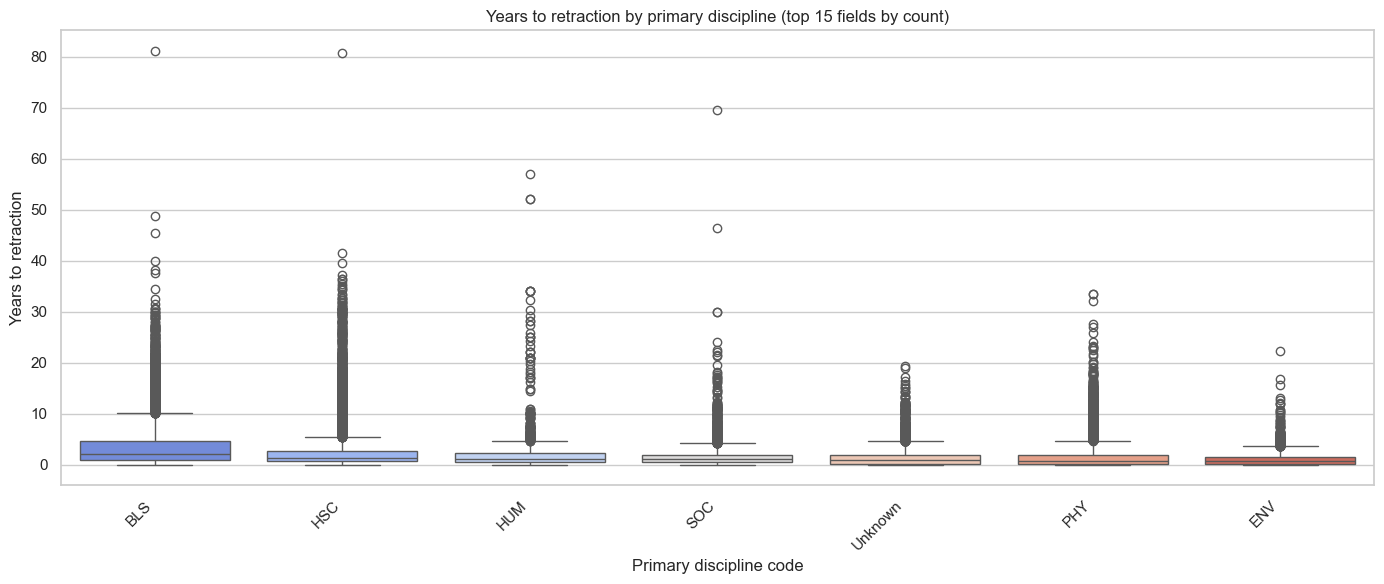

In [6]:
# Top disciplines by volume (exclude Unknown for cleaner plots, or keep — we keep all for counts but filter for boxplots)
TOP_N_FIELDS = 15
top_fields = df["primary_code"].value_counts().head(TOP_N_FIELDS).index.tolist()
df_topf = df[df["primary_code"].isin(top_fields)].copy()

order_by_median = (
    df_topf.groupby("primary_code")["years_to_retraction"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_topf,
    x="primary_code",
    y="years_to_retraction",
    order=order_by_median,
    palette="coolwarm",
)
plt.xticks(rotation=45, ha="right")
plt.title(f"Years to retraction by primary discipline (top {TOP_N_FIELDS} fields by count)")
plt.xlabel("Primary discipline code")
plt.ylabel("Years to retraction")
plt.tight_layout()
plt.show()

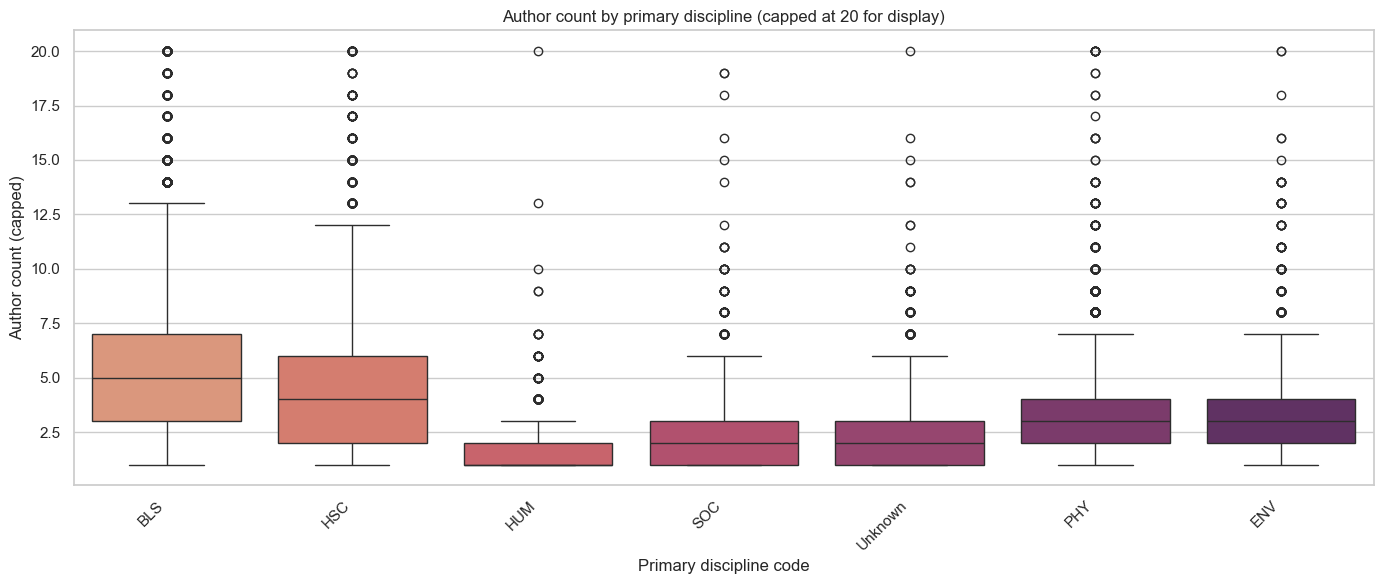

In [7]:
# Author count by field (clip for readability)
df_topf["author_count_clip"] = df_topf["author_count"].clip(upper=20)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_topf,
    x="primary_code",
    y="author_count_clip",
    order=order_by_median,
    palette="flare",
)
plt.xticks(rotation=45, ha="right")
plt.title("Author count by primary discipline (capped at 20 for display)")
plt.xlabel("Primary discipline code")
plt.ylabel("Author count (capped)")
plt.tight_layout()
plt.show()

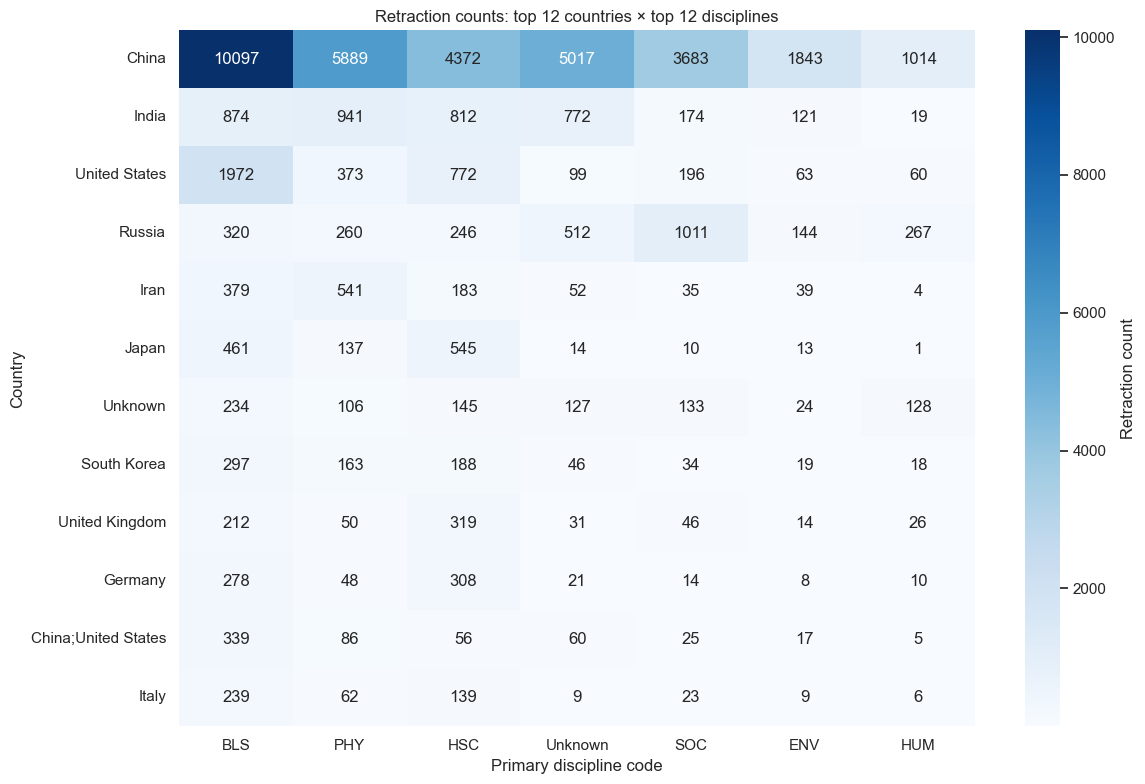

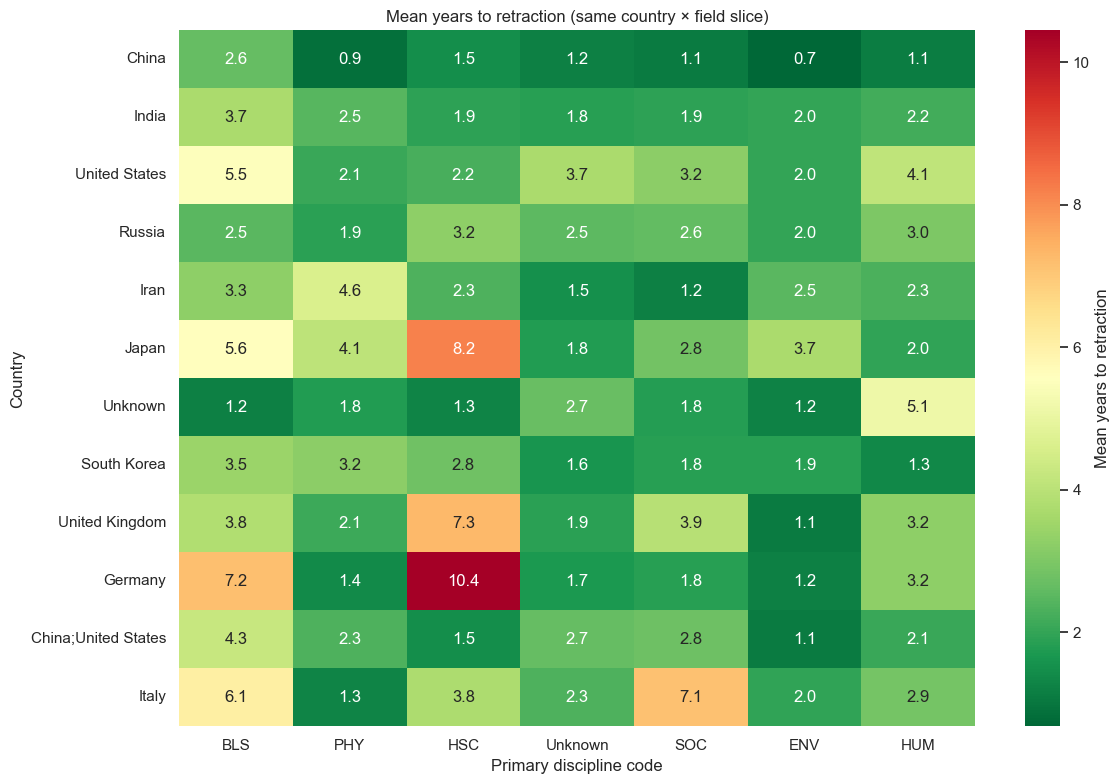

In [8]:
# Country × field: counts heatmap (top countries × top fields)
K_COUNTRIES = 12
M_FIELDS = 12

top_c = df["country"].value_counts().head(K_COUNTRIES).index
top_f = df["primary_code"].value_counts().head(M_FIELDS).index
sub = df[df["country"].isin(top_c) & df["primary_code"].isin(top_f)]

ct = pd.crosstab(sub["country"], sub["primary_code"])
# Order rows/cols by total
ct = ct.reindex(index=ct.sum(axis=1).sort_values(ascending=False).index)
ct = ct[ct.sum(axis=0).sort_values(ascending=False).index]

plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Retraction count"})
plt.title(f"Retraction counts: top {K_COUNTRIES} countries × top {M_FIELDS} disciplines")
plt.xlabel("Primary discipline code")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Mean years to retraction (same slice)
pivot_mean = sub.pivot_table(
    values="years_to_retraction",
    index="country",
    columns="primary_code",
    aggfunc="mean",
)
pivot_mean = pivot_mean.reindex(index=ct.index)
pivot_mean = pivot_mean[ct.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    cbar_kws={"label": "Mean years to retraction"},
)
plt.title("Mean years to retraction (same country × field slice)")
plt.xlabel("Primary discipline code")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

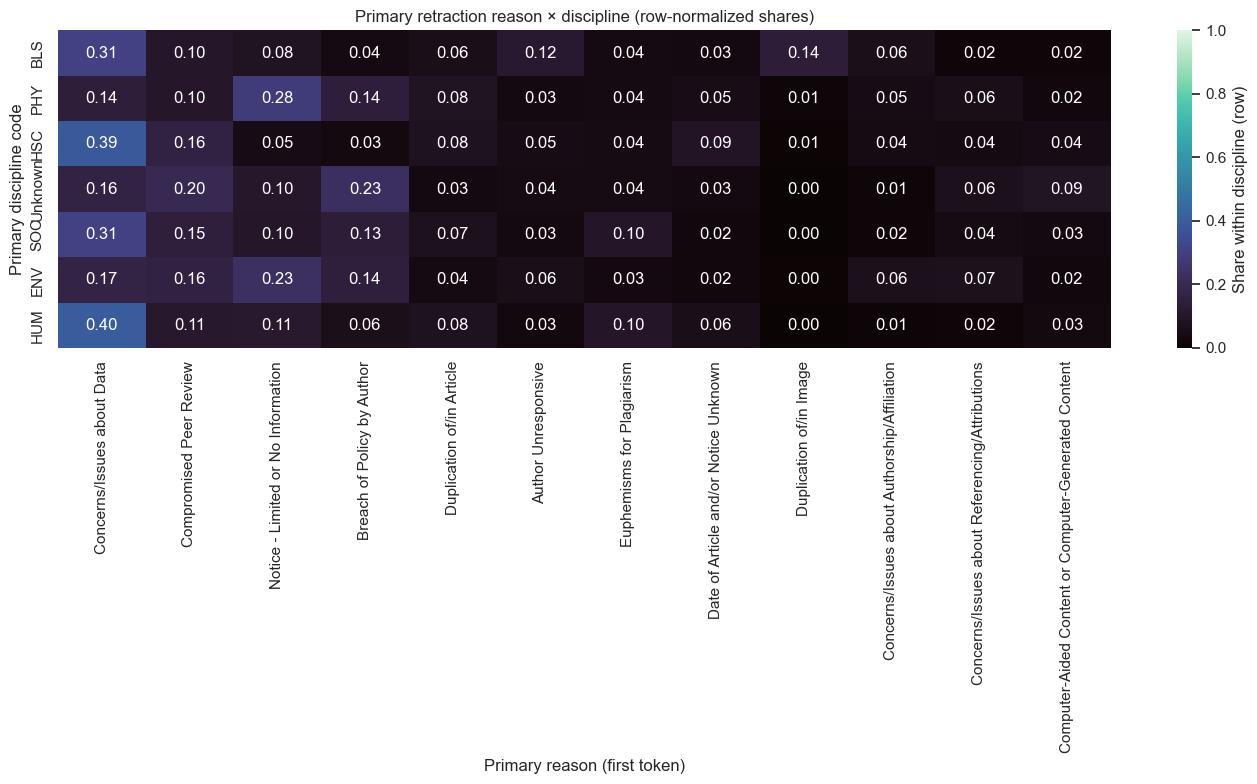

In [9]:
# Primary retraction reason (first segment before ';') × discipline — row-normalized proportions


def primary_reason(reason: str) -> str:
    if pd.isna(reason) or not str(reason).strip():
        return "Unknown"
    part = str(reason).split(";")[0].strip()
    return part if part else "Unknown"


df["primary_reason"] = df["reason"].map(primary_reason)

N_REASONS = 12
top_reasons = df["primary_reason"].value_counts().head(N_REASONS).index
fields_for_reason = df["primary_code"].value_counts().head(12).index
sub_r = df[df["primary_reason"].isin(top_reasons) & df["primary_code"].isin(fields_for_reason)]

cr = pd.crosstab(sub_r["primary_code"], sub_r["primary_reason"])
cr = cr[cr.sum(axis=0).sort_values(ascending=False).index]
cr = cr.reindex(cr.sum(axis=1).sort_values(ascending=False).index)

cr_prop = cr.div(cr.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(
    cr_prop,
    annot=True,
    fmt=".2f",
    cmap="mako",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Share within discipline (row)"},
)
plt.title("Primary retraction reason × discipline (row-normalized shares)")
plt.xlabel("Primary reason (first token)")
plt.ylabel("Primary discipline code")
plt.tight_layout()
plt.show()

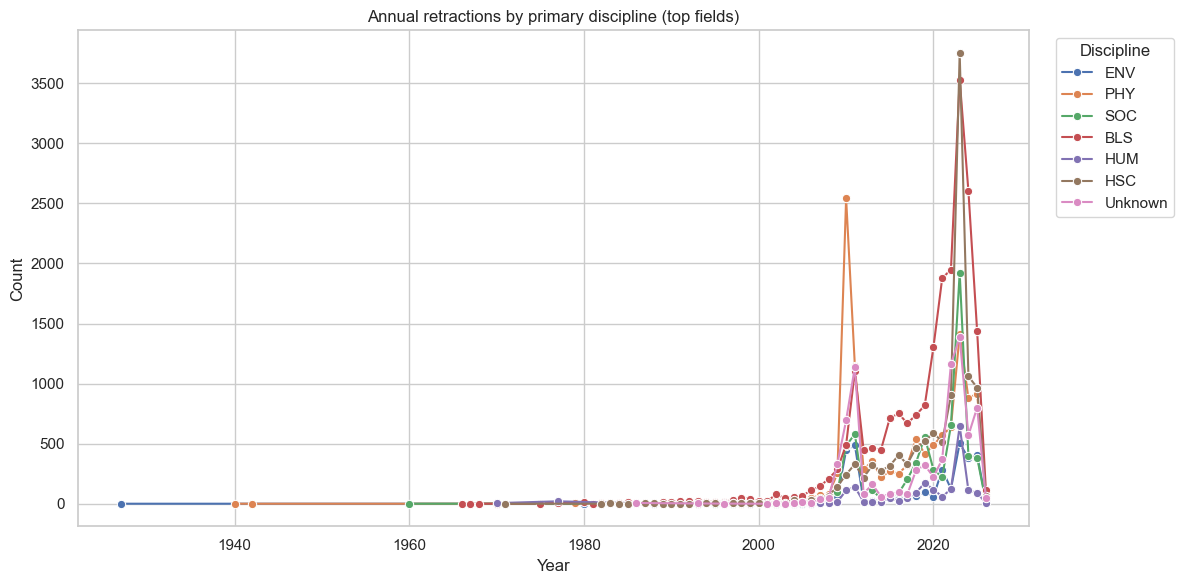

In [10]:
# Retractions per year by top disciplines
TOP_LINES = 8
fields_line = df["primary_code"].value_counts().head(TOP_LINES).index
df_line = df[df["primary_code"].isin(fields_line)]
yearly = (
    df_line.groupby(["retraction_year", "primary_code"])
    .size()
    .reset_index(name="n")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly,
    x="retraction_year",
    y="n",
    hue="primary_code",
    marker="o",
    linewidth=1.5,
)
plt.title("Annual retractions by primary discipline (top fields)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Discipline", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()